# CIR Model — Stochastic Interest Rate Modelling
# Finance Club, IIT Roorkee — Open Project 2026

In [ ]:
from google.colab import files  ## adfd the train data here
uploaded=files.upload()

Saving train_data.csv to train_data.csv


In [ ]:
from google.colab import files ## add the test data here
uploaded=files.upload()

Saving test_data.csv to test_data.csv


In [ ]:
from google.colab import files ## add the test_3m data here
uploaded=files.upload()

Saving test_data_3M.csv to test_data_3M.csv


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
train_df     = pd.read_csv('train_data.csv')
test_df      = pd.read_csv('test_data.csv')
test_3m_df   = pd.read_csv('test_data_3M.csv')

# to convert date column into datetime

In [3]:
train_df['Date']   = pd.to_datetime(train_df['Date'])
test_df['Date']    = pd.to_datetime(test_df['Date'])
test_3m_df['Date'] = pd.to_datetime(test_3m_df['Date'])

In [4]:
print(f"\n Train Data  : {train_df.shape[0]} rows, {train_df.shape[1]} columns")
print(f" Test Data   : {test_df.shape[0]} rows, {test_df.shape[1]} columns")
print(f" Test 3M Data: {test_3m_df.shape[0]} rows, {test_3m_df.shape[1]} columns")

print(f"\n Train period: {train_df['Date'].min().date()} to {train_df['Date'].max().date()}")
print(f"Test period : {test_df['Date'].min().date()} to {test_df['Date'].max().date()}")


 Train Data  : 1976 rows, 10 columns
 Test Data   : 495 rows, 6 columns
 Test 3M Data: 495 rows, 2 columns

 Train period: 2016-05-19 to 2024-04-26
Test period : 2024-04-29 to 2026-04-29


In [5]:
train_df.head()

,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
0,2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
1,2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2,2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793
3,2016-05-25,0.005351,0.005603,0.005809,0.006014,0.006281,0.008323,0.014548,0.021596,0.020855
4,2016-05-26,0.005354,0.005605,0.005811,0.006016,0.006115,0.007934,0.013937,0.021326,0.020591


# Renaming the column name

In [6]:
rename_columns = {
    'ZC025YR' : '3M',
    'ZC050YR' : '6M',
    'ZC075YR' : '9M',
    'ZC100YR' : '1Y',
    'ZC200YR' : '2Y',
    'ZC500YR' : '5Y',
    'ZC1000YR': '10Y',
    'ZC2000YR': '20Y',
    'ZC3000YR': '30Y'
}

In [7]:
train_df.head()

,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
0,2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
1,2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2,2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793
3,2016-05-25,0.005351,0.005603,0.005809,0.006014,0.006281,0.008323,0.014548,0.021596,0.020855
4,2016-05-26,0.005354,0.005605,0.005811,0.006016,0.006115,0.007934,0.013937,0.021326,0.020591


In [8]:
train_df.columns = ['Date','3M','6M','9M','1Y','2Y','5Y','10Y','20Y','30Y']

In [9]:
test_df.columns = ['Date','3M','6M','9M','1Y','2Y']

In [10]:
test_3m_df.columns = ['Date','3M']

In [11]:
train_df.columns

Index(['Date', '3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y'], dtype='object')

In [12]:
train_df.head()

,Date,3M,6M,9M,1Y,2Y,5Y,10Y,20Y,30Y
0,2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
1,2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2,2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793
3,2016-05-25,0.005351,0.005603,0.005809,0.006014,0.006281,0.008323,0.014548,0.021596,0.020855
4,2016-05-26,0.005354,0.005605,0.005811,0.006016,0.006115,0.007934,0.013937,0.021326,0.020591


# Missing values checking

In [13]:
train_df.isnull().sum()

,0
Date,0
3M,0
6M,0
9M,0
1Y,0
2Y,0
5Y,0
10Y,0
20Y,0
30Y,0


In [14]:
test_df.isnull().sum()

,0
Date,0
3M,0
6M,0
9M,0
1Y,0
2Y,0


## Train and test data have no missing values

# Outlier Detection aur Removal

<Axes: xlabel='30Y', ylabel='Density'>

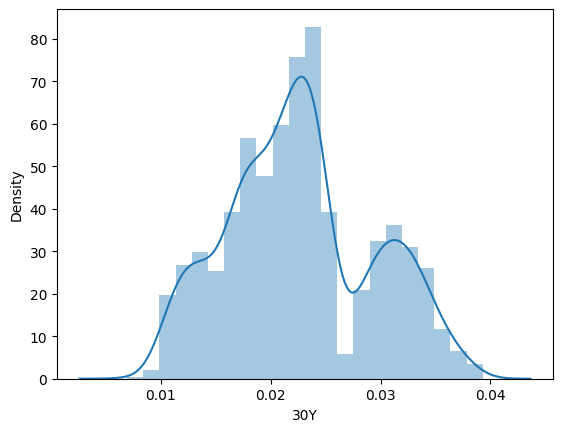

In [15]:
sns.distplot(train_df['30Y'])

since  the columns are skewed from the mean value we are applying IQR to detect and correct the outliers

In [16]:
train_df_cols = ['3M','6M','9M','1Y','2Y','5Y','10Y','20Y','30Y']

In [17]:
new_cols=['3M', '6M', '9M', '1Y', '2Y']

In [18]:
def remove_outliers_iqr(df, cols, factor=3.0):  ## factor 3 ,as we are removing only the extreme outliers , as any minor difference in the interest rate from the normal tred is possible.due to market shock
    df_clean = df.copy()
    total_outliers = 0

    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR

        mask = ((df_clean[col] < lower) | (df_clean[col] > upper))
        count = mask.sum()
        total_outliers += count

        if count > 0:
            print(f"  {col}: {count} outliers found (range: {lower:.4f} to {upper:.4f})")
            df_clean.loc[mask, col] = np.nan

        df_clean[cols] = df_clean[cols].ffill().bfill()


    print(f"\n Total outliers removed: {total_outliers}")
    return df_clean


print("Outlier Removal in Train Data")
train_df = remove_outliers_iqr(train_df, new_cols)

print("\nOutlier Removal in Test Data")
test_df = remove_outliers_iqr(test_df, new_cols)

Outlier Removal in Train Data

 Total outliers removed: 0

Outlier Removal in Test Data

 Total outliers removed: 0


In [19]:
train_df['3M'].shape ## all the outliers are being replaced by previous and afterwards values

(1976,)

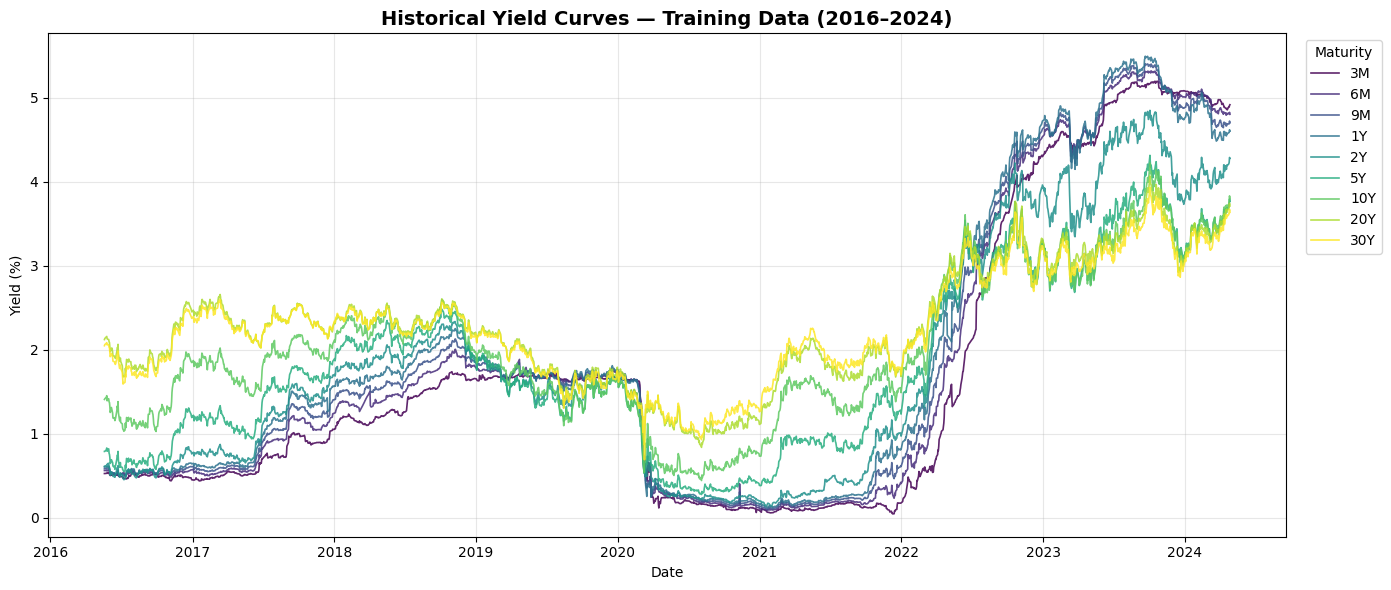

In [20]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(train_df_cols)))

for col, color in zip(train_df_cols, colors):
    ax.plot(train_df['Date'], train_df[col] * 100,
            label=col, color=color, linewidth=1.2, alpha=0.85)

ax.set_title('Historical Yield Curves — Training Data (2016–2024)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Yield (%)')
ax.legend(title='Maturity', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

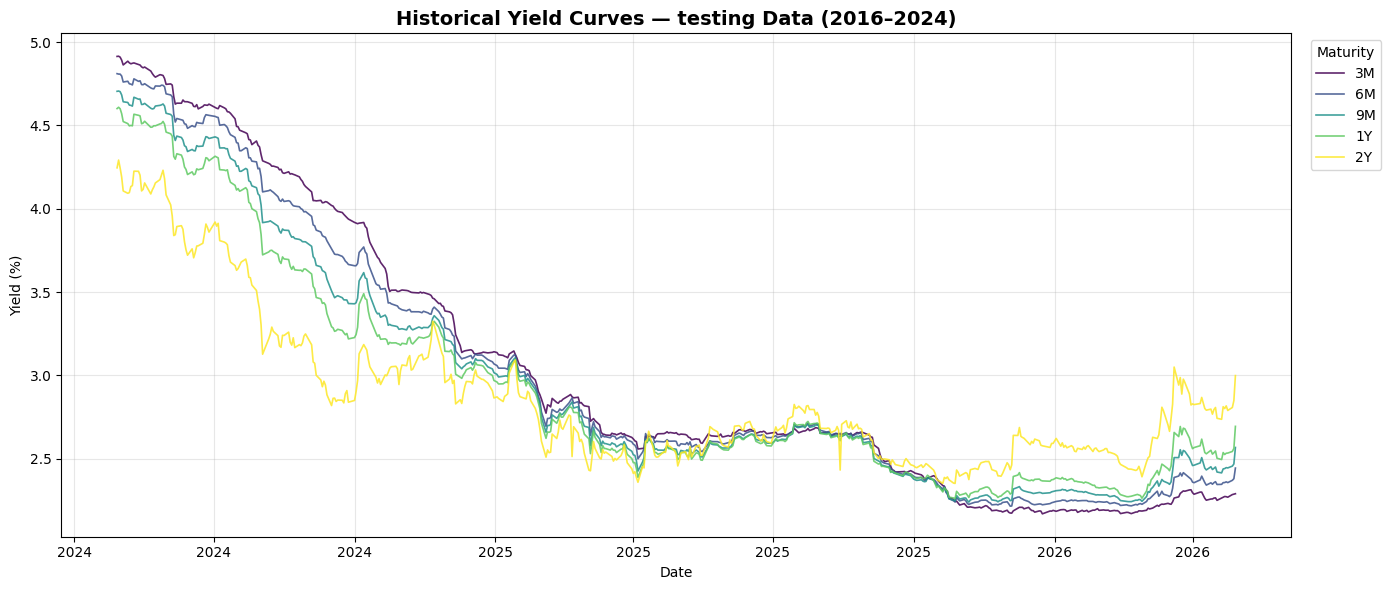

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(new_cols)))

for col, color in zip(new_cols, colors):
    ax.plot(test_df['Date'], test_df[col] * 100,
            label=col, color=color, linewidth=1.2, alpha=0.85)

ax.set_title('Historical Yield Curves — testing Data (2016–2024)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Yield (%)')
ax.legend(title='Maturity', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

kappa(k)= k is the mean reversion speed , it tells how fast or slow the rates come towards the mean value , **(half life=ln(2)/k)** In our data when we calibrated OLS method for last 600 days then k comess out to be 0.77 that means it takes about near 226 days for the rates to become half of the mean value in recent market comndition

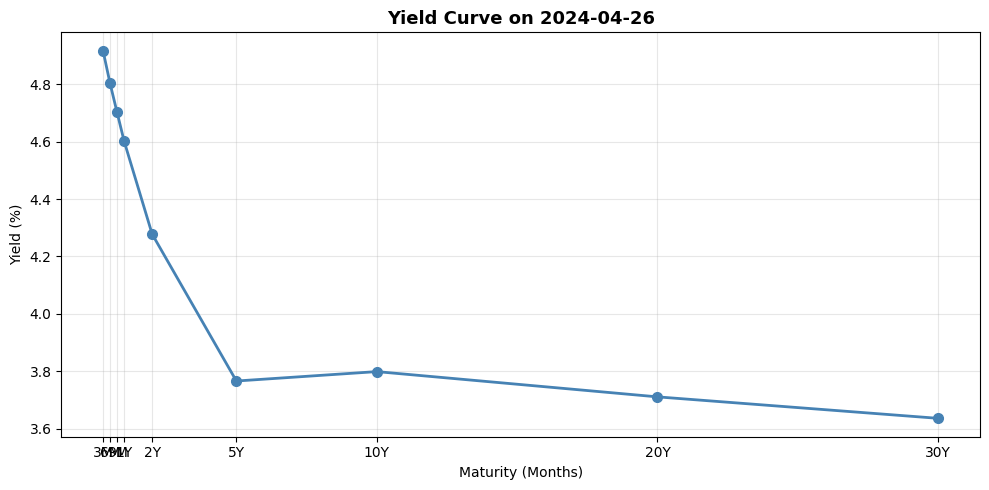

In [22]:
maturities_months = [3, 6, 9, 12, 24, 60, 120, 240, 360]
last_row = train_df.iloc[-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(maturities_months, last_row[train_df_cols].values * 100,
        marker='o', linewidth=2, color='steelblue', markersize=7)

ax.set_title(f"Yield Curve on {last_row['Date'].date()}",
             fontsize=13, fontweight='bold')
ax.set_xlabel('Maturity (Months)')
ax.set_ylabel('Yield (%)')
ax.set_xticks(maturities_months)
ax.set_xticklabels(train_df_cols)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Possible reasons for decreasing maturity yeilds for long term maturity period

# Markets expect that future rate will be decrese due to inflation , unemployment so investors,banks and financial corporation buys the long term yeild impacts in increase in the bond price of long term yeilds and decrease in yeild(%).

In [23]:

print(f"\n Train Data  : {train_df.shape[0]} rows , {train_df.shape[1]} cols")
print(f"   Period      : {train_df['Date'].min().date()} to  {train_df['Date'].max().date()}")
print(f"   Missing     : {train_df[new_cols].isnull().sum().sum()}")

print(f"\n Test Data   : {test_df.shape[0]} rows , {test_df.shape[1]} cols")
print(f"   Period      : {test_df['Date'].min().date()} to  {test_df['Date'].max().date()}")
print(f"   Missing     : {test_df[new_cols].isnull().sum().sum()}")

print(f"\n Test 3M     : {test_3m_df.shape[0]} rows , {test_3m_df.shape[1]} cols")

print(f"\n Train Yield Stats (%):")
print((train_df[new_cols] * 100).describe().round(3).to_string())




 Train Data  : 1976 rows , 10 cols
   Period      : 2016-05-19 to  2024-04-26
   Missing     : 0

 Test Data   : 495 rows , 6 cols
   Period      : 2024-04-29 to  2026-04-29
   Missing     : 0

 Test 3M     : 495 rows , 2 cols

 Train Yield Stats (%):
             3M        6M        9M        1Y        2Y
count  1976.000  1976.000  1976.000  1976.000  1976.000
mean      1.670     1.789     1.853     1.917     1.806
std       1.664     1.676     1.665     1.659     1.366
min       0.049     0.088     0.105     0.123     0.142
25%       0.462     0.519     0.545     0.573     0.590
50%       1.191     1.382     1.530     1.633     1.547
75%       1.711     1.938     2.108     2.274     2.555
max       5.196     5.320     5.404     5.494     4.850


In [24]:
from scipy.optimize import minimize
from scipy.stats import norm

Firtly calculating the Mathematical Parameters A and B in the bond price formula

In [25]:
def cir_B(tau, kappa, sigma):

    gamma = np.sqrt(kappa**2 + 2 * sigma**2)
    num   = 2 * (np.exp(gamma * tau) - 1)
    den   = (gamma + kappa) * (np.exp(gamma * tau) - 1) + 2 * gamma
    return num / den

    ## tau=time to maturity
    ## kappa=mean reversion speed
    ## sigma=volatility

In [26]:
def cir_A(tau, kappa, theta, sigma):

    gamma = np.sqrt(kappa**2 + 2 * sigma**2)
    num   = 2 * gamma * np.exp((kappa + gamma) * tau / 2)
    den   = (gamma + kappa) * (np.exp(gamma * tau) - 1) + 2 * gamma
    power = (2 * kappa * theta) / sigma**2
    return (num / den) ** power

    ## theta=lung run mean

In [27]:
def cir_yield(tau, r0, kappa, theta, sigma):
    if np.isscalar(tau):
        if tau <= 0:
            return r0
    B = cir_B(tau, kappa, sigma)
    A = cir_A(tau, kappa, theta, sigma)
    P = A * np.exp(-B * r0)
    y = -np.log(P) / tau
    return y

## above function defined for the calculation of the bond price

In [28]:
maturities = {
    '3M' : 0.25,
    '6M' : 0.50,
    '9M' : 0.75,
    '1Y' : 1.00,
    '2Y' : 2.00,
    '5Y' : 5.00,
    '10Y': 10.0,
    '20Y': 20.0,
    '30Y': 30.0
}

In [29]:
predict_cols = ['6M','9M','1Y','2Y']

In [30]:
train_cols = ['6M','9M','1Y','2Y','5Y','10Y','20Y','30Y']

In [31]:
taus         = [maturities[c] for c in train_cols]

In [32]:
## using MLE caliberation

In [33]:
from sklearn.metrics import r2_score, mean_squared_error

In [34]:
from scipy.stats import ncx2
from scipy.optimize import differential_evolution
from scipy.optimize import minimize
from sklearn.metrics import r2_score

In [35]:
def panel_loss(params):
    kappa, theta, sigma = params
    if kappa <= 0 or theta <= 0 or sigma <= 0:
        return 1e10
    if 2 * kappa * theta < sigma**2:
        return 1e10
    loss = 0
    for i in range(0, len(train_r0), 10):  # taking every 10th day rate
        r0 = train_r0[i]

        for j, tau in enumerate(taus):      # for every maturity
            y_pred   = cir_yield(tau, r0, kappa, theta, sigma)
            y_actual = train_yields[i, j]
            loss    += (y_pred - y_actual)**2  # squared error

    return loss




In [36]:
bounds = [(0.001, 3.0),  #range of kappa
          (0.001, 0.15),  # range of theta
          (0.001, 0.5)]   # range of sigma

train_r0     = train_df['3M'].values
train_yields = train_df[train_cols].values
print(f"Training samples: {len(train_r0)} days  and {len(predict_cols)} maturities")

Training samples: 1976 days  and 4 maturities


In [37]:
result = differential_evolution(
    panel_loss,
    bounds,
    seed      = 42,      # Reproducibility
    maxiter   = 1000,    # Maximum iterations
    popsize   = 15,      # Population size
    tol       = 1e-10,   # Convergence tolerance
    workers   = 1
)

kappa, theta, sigma = result.x

In [38]:
kappa, theta, sigma = result.x

In [39]:
print(f"  κ (kappa) = {kappa:.4f}  — mean reversion speed")
print(f"  θ (theta) = {theta:.4f}  — long run mean ({theta*100:.2f}%)")
print(f"  σ (sigma) = {sigma:.4f}  — volatility")

  κ (kappa) = 0.1638  — mean reversion speed
  θ (theta) = 0.0244  — long run mean (2.44%)
  σ (sigma) = 0.0010  — volatility


# why we doesn't used **OLS** or other calibration methodology for the base CIR : OLS method analyzes the short term trend and gives out out negative kappa(mean-reversion speed) which is a economically meaningless prediction ,**MlE** is preffered becouse it find outs the best k,theta and sigma that fits in the whole training period(1976)days.


In [40]:
##Feller condition
feller=2*kappa*theta
feller_sat=feller>=sigma**2
print(f"  Feller Satisfied: {' YES' if feller_sat else ' NO'}")
print(feller,sigma**2)

  Feller Satisfied:  YES
0.008002188890271641 1.000003344852918e-06


# In what condition feller may fails:
#1.In covid periods when the volatility is too high 2κθ < σ**2 or when k is negative (as we get in ols) the feller is violated,

#we handled the feller condition by rejecting those parameters **(if 2 * kappa * theta < sigma2:
 #       return 1e10)**
 # and bounding the parameters to aviod violation.**(bounds = [(0.001, 3.0),   range of kappa
          (0.001, 0.15),   range of theta
          (0.001, 0.5)] )**

In [41]:
def predict_yield_curve(r0, kappa, theta, sigma, predict_cols_cols, maturities): ## prediction of maturities(6M to 30Y) from one day rate
  return {col: cir_yield(maturities[col], r0, kappa, theta, sigma)
            for col in predict_cols}

In [42]:
def predict_all(test_3m_df, kappa, theta, sigma, predict_cols, maturities): ## prediction of maturities (6M to 30Y) from all trading days of 3M maturity

    results = []
    for _, row in test_3m_df.iterrows():
        r0   = row['3M']
        pred = predict_yield_curve(r0, kappa, theta, sigma, predict_cols, maturities)
        pred['Date'] = row['Date']
        results.append(pred)
    return pd.DataFrame(results).set_index('Date')

In [43]:
pred_df       = predict_all(test_3m_df, kappa, theta, sigma, predict_cols, maturities)
actual_df     = test_df.set_index('Date')[predict_cols]
common_dates  = pred_df.index.intersection(actual_df.index)
pred_aligned  = pred_df.loc[common_dates]
actual_aligned = actual_df.loc[common_dates]

In [44]:
common_dates.shape

(495,)

In [45]:
actual_aligned.shape

(495, 4)

In [46]:
pred_aligned.shape

(495, 4)

In [47]:
r2_scores = {}
for col in predict_cols:
    r2   = r2_score(actual_aligned[col], pred_aligned[col])
    rmse = np.sqrt(np.mean((actual_aligned[col] - pred_aligned[col])**2)) * 100
    r2_scores[col] = r2
    print(f"  {col:4s}: R² = {r2:.4f}   RMSE = {rmse:.4f}%  ")
overall_r2 = r2_score(
    actual_aligned.values.flatten(),
    pred_aligned.values.flatten())


print(f"  Overall out of ssample R² = {overall_r2:.4f}  "
      f"{'PASS' if overall_r2 > 0.85 else 'does not pass'}")


  6M  : R² = 0.9944   RMSE = 0.0591%  
  9M  : R² = 0.9672   RMSE = 0.1307%  
  1Y  : R² = 0.9094   RMSE = 0.1981%  
  2Y  : R² = 0.3845   RMSE = 0.3669%  
  Overall out of ssample R² = 0.8922  PASS


## what are the possible reasons for the negative R2 score of the base CIR model in Long term maturities prediction

## 1. Base CIR model is a one factor model that assumes either the long run mean is shorther or larger (to be a constatnt quantity) than the current interest rate but in real economy the mean varies as depicted in the above graph of HIstorical yeild curve due to market sentiments,new monetary policy or inflation when we have the view on a long term rates.



## 2.One of the important reason can be that CIR model assumes continious path(either decreasing or increasing) but in real world market behaviour can include sudden changes due to market behavious in long term yeilds

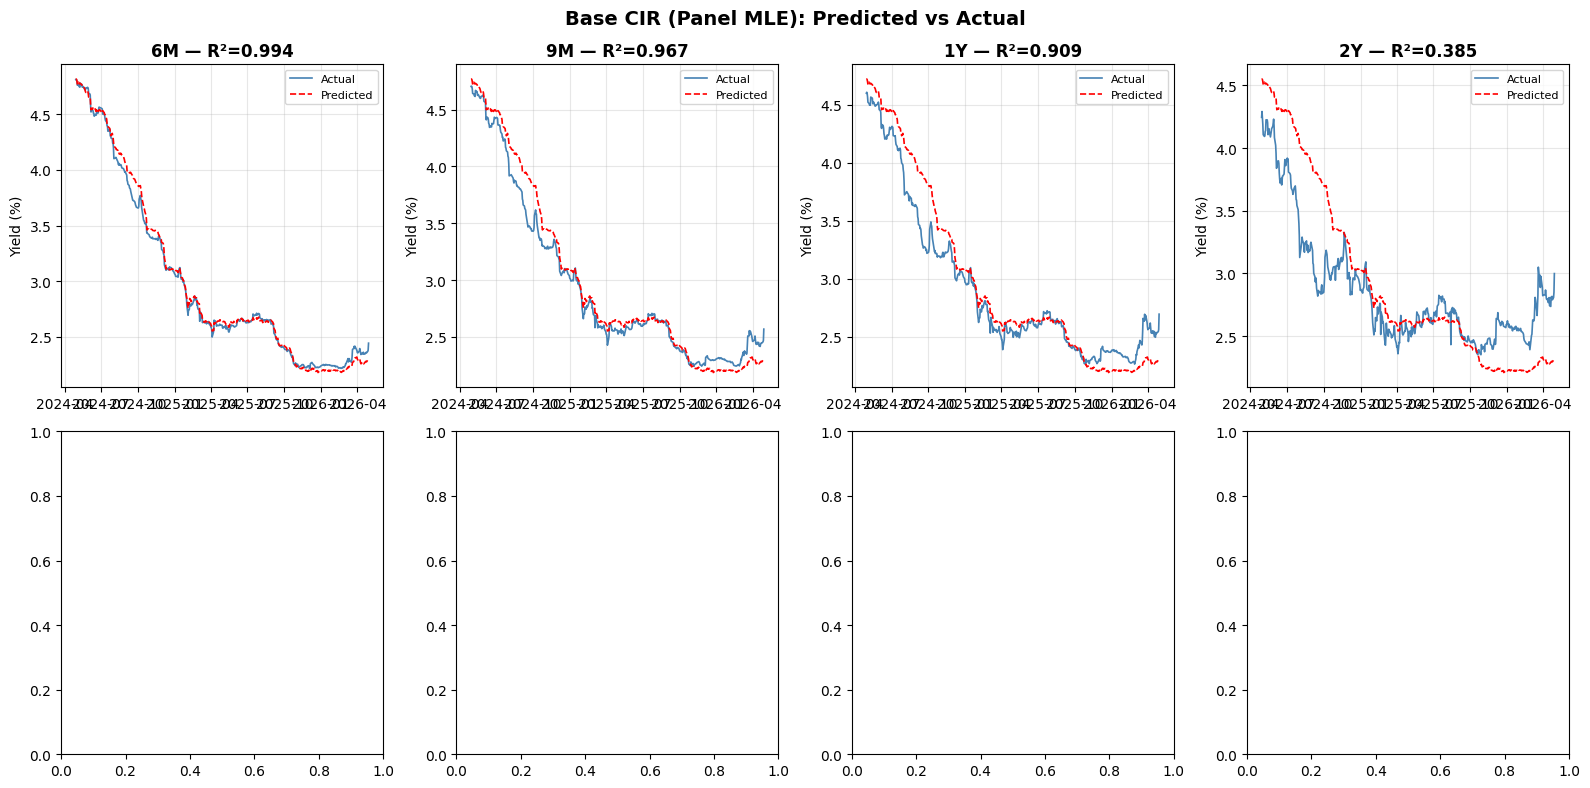

In [48]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(predict_cols):
    axes[i].plot(actual_aligned.index, actual_aligned[col]*100,
                 label='Actual', color='steelblue', linewidth=1.2)
    axes[i].plot(pred_aligned.index, pred_aligned[col]*100,
                 label='Predicted', color='red', linewidth=1.2, linestyle='--')
    axes[i].set_title(f'{col} — R²={r2_scores[col]:.3f}', fontweight='bold')
    axes[i].set_ylabel('Yield (%)')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Base CIR (Panel MLE): Predicted vs Actual', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# CIR alone can predict the entire yeild curve(6M to 30Y) becouse CIR assumes that all the yeilds are driven by single factor the short rate.

# CIR consistently OVERESTIMATES
# long maturities during test period!

# Following are the reasons:

#1. Inverted curve not captured:
# Test period: 3M (5.3%) > 30Y (3.8%)
# CIR sees 3M = 5.3% , predicts 30Y = 4.8%
#  Actual 30Y = 3.8% ,overestimate by 1%


# **Why Short Maturities Are Better:**
#  6M = 3M by nature (both Fed policy driven)
#  Small τ couses B(τ) large and  r0 dominates prediction
#  Systematic bias is small

In [49]:
##Extension - Two Factor CIR

In [50]:
def cir_B(tau, kappa, sigma):
    """Single factor B function"""
    gamma  = np.sqrt(kappa**2 + 2 * sigma**2)
    exp_gt = np.exp(np.clip(gamma * tau, 0, 500))
    num    = 2 * (exp_gt - 1)
    den    = (gamma + kappa) * (exp_gt - 1) + 2 * gamma
    return num / den


def cir_A(tau, kappa, theta, sigma):
    """Single factor A function"""
    gamma    = np.sqrt(kappa**2 + 2 * sigma**2)
    exp_gt   = np.exp(np.clip(gamma * tau, 0, 500))
    exp_half = np.exp(np.clip((kappa + gamma) * tau / 2, 0, 500))
    num      = 2 * gamma * exp_half
    den      = (gamma + kappa) * (exp_gt - 1) + 2 * gamma
    power    = (2 * kappa * theta) / sigma**2
    return np.clip((num / den) ** power, 1e-10, 1e10)


def two_factor_yield(tau, r1, r2,                       ## tau=maturities,r1=short term rate,r2=long term rate
                     kappa1, theta1, sigma1,
                     kappa2, theta2, sigma2):

    if tau <= 0:
        return r1 + r2

    try:
        # Factor 1 contribution
        B1 = cir_B(tau, kappa1, sigma1)
        A1 = cir_A(tau, kappa1, theta1, sigma1)

        # Factor 2 contribution
        B2 = cir_B(tau, kappa2, sigma2)
        A2 = cir_A(tau, kappa2, theta2, sigma2)

        # Combined bond price
        P  = A1 * A2 * np.exp(-B1*r1 - B2*r2)

        if P <= 0 or not np.isfinite(P):
            return r1 + r2

        return max(-np.log(P) / tau, 0)

    except:
        return r1 + r2

In [51]:
maturities = {
    '3M' : 0.25, '6M' : 0.50, '9M' : 0.75,
    '1Y' : 1.00, '2Y' : 2.00, '5Y' : 5.00,
    '10Y': 10.0, '20Y': 20.0, '30Y': 30.0
}

predict_cols = ['6M','9M','1Y','2Y' ]
train_cols = ['6M','9M','1Y','2Y','5Y','10Y','20Y','30Y']
taus         = [maturities[c] for c in train_cols]

In [52]:
##  r1t and  r2t Split Function

def split_r(r0, alpha): ##to split the 3M rate into r1t and r2t

    r1 = alpha * r0
    r2 = (1 - alpha) * r0
    return r1, r2

## MLE calibration for the two factor CIR

def two_factor_loss(parameter):

    kappa1, theta1, sigma1, \
    kappa2, theta2, sigma2, \
    alpha = parameter

    if any(p <= 0 for p in [kappa1, theta1, sigma1,
                             kappa2, theta2, sigma2]):
        return 1e10

    if not (0.1 <= alpha <= 0.9):
        return 1e10

    # Feller conditions
    if 2*kappa1*theta1 <= sigma1**2:
        return 1e10
    if 2*kappa2*theta2 <= sigma2**2:
        return 1e10


    if kappa1 <= kappa2: ## kappa 1 determines the mean reversion speed for short term maturities so it should be more than kappa 2
        return 1e10

    loss = 0


    for i in range(0, len(train_r0), 20):
        r0       = train_r0[i]
        r1, r2   = split_r(r0, alpha)

        for j, tau in enumerate(taus):
            y_pred   = two_factor_yield(
                            tau, r1, r2,
                            kappa1, theta1, sigma1,
                            kappa2, theta2, sigma2
                       )
            y_actual = train_yields[i, j]
            loss    += (y_pred - y_actual) ** 2

    return loss


train_r0     = train_df['3M'].values
train_yields = train_df[train_cols].values

print(f"Training: {len(train_r0)} days and {len(train_cols)} maturities")


print("   (executing differential evaluation it may take upto 10-12 mins)\n")

bounds = [
    (0.5,   5.0),    # kappa1 — fast mean reversion
    (0.001, 0.10),   # theta1 — short term mean
    (0.001, 0.30),   # sigma1 — short term volatility
    (0.001, 0.50),   # kappa2 — slow mean reversion
    (0.001, 0.10),   # theta2 — long term mean
    (0.001, 0.20),   # sigma2 — long term volatility
    (0.1,   0.9),    # alpha  — split ratio
]

result = differential_evolution(
    two_factor_loss,
    bounds,
    seed     = 42,
    maxiter  = 300,
    popsize  = 8,
    tol      = 1e-10,
    workers  = -1
)

Training: 1976 days and 8 maturities

 Two Factor CIR calibrating...
   (executing differential evaluation it may take upto 10-12 mins)



In [53]:
kappa1, theta1, sigma1, \
kappa2, theta2, sigma2, \
alpha = result.x

print("   Two Factor CIR Parameters :")
print(f"  Factor 1 (Short Term):")
print(f"    κ1 = {kappa1:.4f}  — fast mean reversion")
print(f"    θ1 = {theta1:.4f}  ({theta1*100:.2f}%)")
print(f"    σ1 = {sigma1:.4f}")
print()
print(f"  Factor 2 (Long Term):")
print(f"    κ2 = {kappa2:.4f}  — slow mean reversion")
print(f"    θ2 = {theta2:.4f}  ({theta2*100:.2f}%)")
print(f"    σ2 = {sigma2:.4f}")
print()
print(f"  Alpha (split ratio) = {alpha:.4f}")
print(f"    r1t = {alpha*100:.1f}% of 3M rate")
print(f"    r2t = {(1-alpha)*100:.1f}% of 3M rate")
print()

# Feller check
f1 = 2*kappa1*theta1 >= sigma1**2
f2 = 2*kappa2*theta2 >= sigma2**2
print(f"  Feller Factor 1: {'feller satisffied' if f1 else 'feller not satisfied'}")
print(f"  Feller Factor 2: {'feller satisfied' if f2 else 'feller not satisfied'}")

   Two Factor CIR Parameters :
  Factor 1 (Short Term):
    κ1 = 0.5000  — fast mean reversion
    θ1 = 0.0114  (1.14%)
    σ1 = 0.1068

  Factor 2 (Long Term):
    κ2 = 0.0484  — slow mean reversion
    θ2 = 0.0162  (1.62%)
    σ2 = 0.0010

  Alpha (split ratio) = 0.5206
    r1t = 52.1% of 3M rate
    r2t = 47.9% of 3M rate

  Feller Factor 1: feller satisffied
  Feller Factor 2: feller satisfied


In [ ]:
## prediction on test_3m

results = []

for i in range(len(test_3m_df)):
    row  = test_3m_df.iloc[i]
    r0   = row['3M']
    date = pd.to_datetime(row['Date'])

    r1, r2 = split_r(r0, alpha)

    pred = {}
    for col in predict_cols:
        tau        = maturities[col]
        pred[col]  = two_factor_yield(
                        tau, r1, r2,
                        kappa1, theta1, sigma1,
                        kappa2, theta2, sigma2
                     )
    pred['Date'] = date
    results.append(pred)

pred_2f         = pd.DataFrame(results)
pred_2f['Date'] = pd.to_datetime(pred_2f['Date'])
pred_2f         = pred_2f.set_index('Date')

print(f"Shape: {pred_2f.shape}")


 ## r2 score for the two factor CIR

actual_df         = test_df.copy()
actual_df['Date'] = pd.to_datetime(actual_df['Date'])
actual_df         = actual_df.set_index('Date')[predict_cols]

common_dates   = pred_2f.index.intersection(actual_df.index)
pred_aligned   = pred_2f.loc[common_dates]
actual_aligned = actual_df.loc[common_dates]


print(f"Common dates: {len(common_dates)},{len(common_dates)}")
print("   Out-of-Sample R² for all the yeild (6M to 2Y)(Two Factor CIR)")

r2_scores_2f = {}
for col in predict_cols:
    r2   = r2_score(actual_aligned[col], pred_aligned[col])
    rmse = np.sqrt(mean_squared_error(
                actual_aligned[col], pred_aligned[col])) * 100
    r2_scores_2f[col] = r2

    print(f"  {col:4s}: R² = {r2:.4f}   RMSE = {rmse:.4f}% ")

overall_r2 = r2_score(
    actual_aligned.values.flatten(),
    pred_aligned.values.flatten()
)
print()
print(f"  Overall R² = {overall_r2:.4f}  "
      f"{' PASS' if overall_r2 > 0.85 else 'Not passes'}")
print()

Shape: (495, 4)
Common dates: 495,495
   Out-of-Sample R² for all the yeild (6M to 2Y)(Two Factor CIR)
  6M  : R² = 0.9957   RMSE = 0.0514% 
  9M  : R² = 0.9790   RMSE = 0.1047% 
  1Y  : R² = 0.9393   RMSE = 0.1622% 
  2Y  : R² = 0.5565   RMSE = 0.3115% 

  Overall R² = 0.9241   PASS



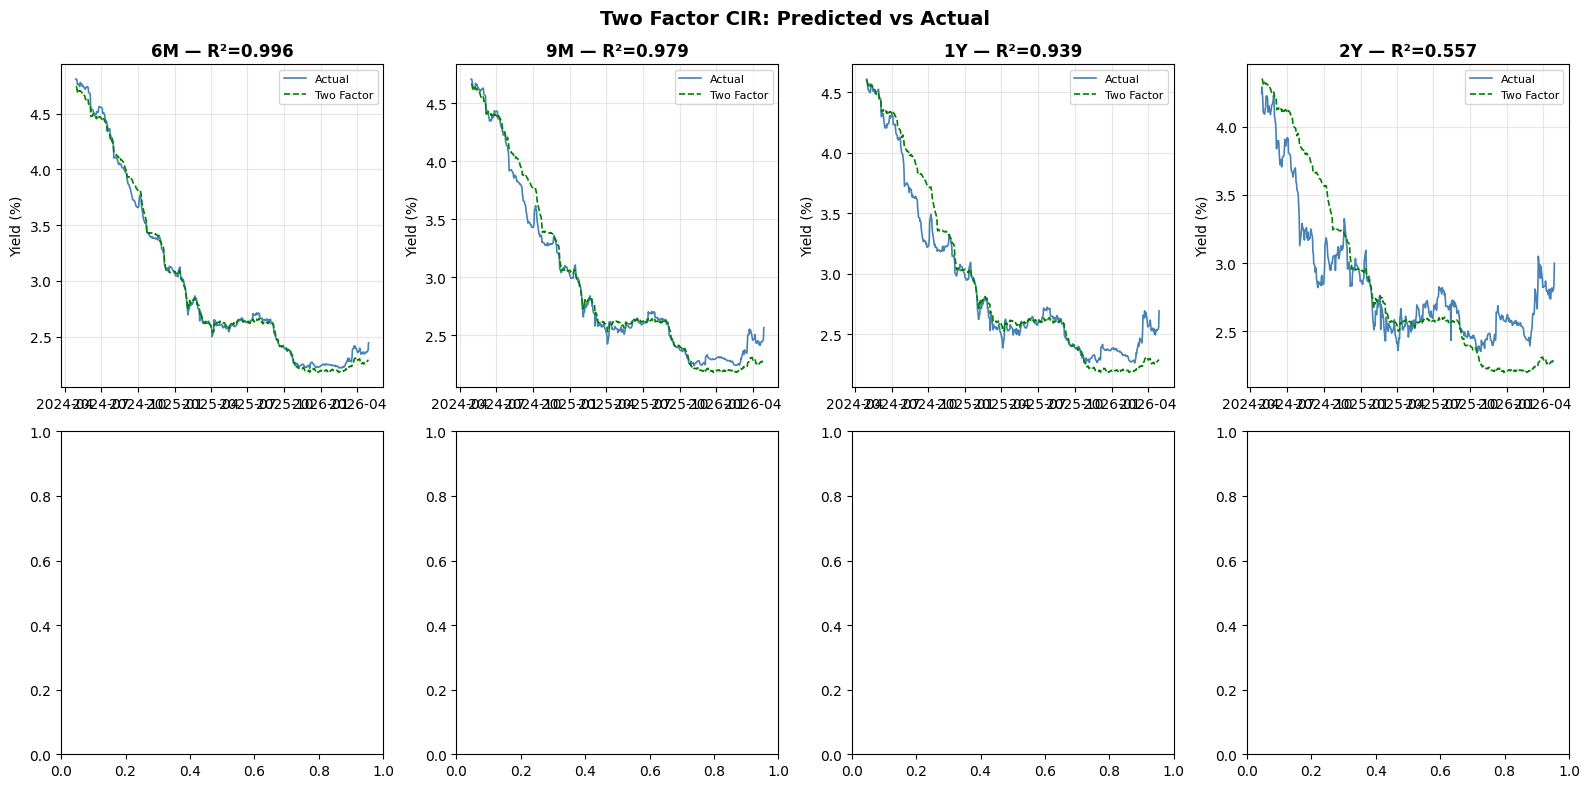

In [ ]:
## Visualization

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(predict_cols):
    axes[i].plot(actual_aligned.index,
                 actual_aligned[col]*100,
                 label='Actual', color='steelblue', linewidth=1.2)
    axes[i].plot(pred_aligned.index,
                 pred_aligned[col]*100,
                 label='Two Factor', color='green',
                 linewidth=1.2, linestyle='--')
    axes[i].set_title(f'{col} — R²={r2_scores_2f[col]:.3f}',
                      fontweight='bold')
    axes[i].set_ylabel('Yield (%)')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Two Factor CIR: Predicted vs Actual',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# why i choses Two factor CIR over alternatives extension?

# CIR++ : our predicted yeild fits with the training period becouse of MLE calibration so the gap(phi) in the CIR++ is almost negligible hence it does not improve the model.

# Jump diffusion process: It fixes the sudden jumps in the short rate but does not improves the inversion of the curve for which out base CIR fails.



# ** Why two factor CIR worked :** : 1. Differential weighting = it splits the short rate into two parts one dominates for the short term maturiies and other for the long term which captures the inversion of the yeild.

# 2. It also splits the parameterms k, theta and sigma into two which better fits on the training data as compared to the base cir , (eg: for two values of theta:
#  theta1 = short term mean
#  theta2 = long term mean

#  Short yields = converges towards theta 1
#  Long yields  = converges towards theta 2

#  if theta2 < theta1:
#  long yeilds are less predicted from theta 1 , hence captures the inversion)


#  what are the additional challenges introduces by it:

#1.optimization of alpha :alpha is being chosen as according to the training dataset which follows a normal curve in one direction trend.

#2.overfitting of the 7 parameters (k1,k2,theta1,theta2,sigma1,sigma2,alpha) in training set may also capture the noise of training set that causes error in testing periods